# DeepEval + BayesProp: Bayesian A/B Testing of LLM Metrics (Paired Laplace)

Compare two fictive LLMs (Model A vs Model B) on the **Answer Relevancy** metric from
[deepeval](https://github.com/confident-ai/deepeval), then test whether the
difference in pass-rates is statistically meaningful using the **paired Laplace test** from
[bayesprop](https://github.com/AVoss84/bayesProp).

### Toy example
1. Define 20 shared evaluation prompts with responses from both models.
2. Build `LLMTestCase` objects and score each with `AnswerRelevancyMetric`.
3. Binarize scores → *pass* (score ≥ threshold) / *fail*.
4. Feed binary arrays into `PairedBayesPropTest` for a paired Bayesian comparison via Laplace approximation.

> **Note:** This notebook simulates deepeval metric scores directly (no LLM judge / API key required).

## 1 — Setup & Imports

In [2]:
# !uv pip install deepeval bayesprop

In [2]:
import numpy as np

from deepeval.test_case import LLMTestCase
#from deepeval.metrics import AnswerRelevancyMetric

from bayesprop.resources.bayes_paired_laplace import PairedBayesPropTest

## 2 — Define Evaluation Data

Same inputs for both models; different `actual_output` quality.

In [3]:
# Shared prompts / questions
inputs = [
    "What is the capital of France?",
    "Explain photosynthesis in one sentence.",
    "What are the benefits of exercise?",
    "How does a combustion engine work?",
    "What causes rain?",
    "Summarize the theory of relativity.",
    "What is machine learning?",
    "Why is the sky blue?",
    "What is the Pythagorean theorem?",
    "Describe how vaccines work.",
    "What is GDP?",
    "How do airplanes fly?",
    "What is the greenhouse effect?",
    "Explain supply and demand.",
    "What is DNA?",
    "How does encryption work?",
    "What is inflation?",
    "Explain the water cycle.",
    "What is an API?",
    "How do neural networks learn?",
]

# Model A — generally high-quality, relevant answers
outputs_model_A = [
    "The capital of France is Paris.",
    "Photosynthesis is the process by which plants convert sunlight, water, and CO2 into glucose and oxygen.",
    "Exercise improves cardiovascular health, strengthens muscles, boosts mood, and helps maintain a healthy weight.",
    "A combustion engine burns fuel in cylinders to create expanding gases that push pistons and generate mechanical power.",
    "Rain is caused by water vapor condensing into droplets in clouds that become heavy enough to fall.",
    "Einstein's theory of relativity describes how space and time are interlinked and how gravity warps spacetime.",
    "Machine learning is a subset of AI where algorithms learn patterns from data to make predictions without explicit programming.",
    "The sky appears blue because shorter blue wavelengths of sunlight scatter more in the atmosphere (Rayleigh scattering).",
    "The Pythagorean theorem states that in a right triangle, a² + b² = c², where c is the hypotenuse.",
    "Vaccines expose the immune system to a weakened or inactivated pathogen so it can build immunity for future encounters.",
    "GDP (Gross Domestic Product) measures the total monetary value of all goods and services produced within a country.",
    "Airplanes fly by generating lift when air moves faster over the curved upper wing surface, creating lower pressure above.",
    "The greenhouse effect traps heat in the atmosphere when gases like CO2 absorb and re-emit infrared radiation.",
    "Supply and demand is the economic model where prices rise when demand exceeds supply and fall when supply exceeds demand.",
    "DNA is a double-helix molecule that carries the genetic instructions for growth, development, and reproduction.",
    "Encryption transforms readable data into ciphertext using algorithms and keys so only authorized parties can decrypt it.",
    "Inflation is the rate at which the general price level of goods and services rises, reducing purchasing power.",
    "The water cycle describes evaporation from surfaces, condensation into clouds, precipitation as rain or snow, and collection.",
    "An API (Application Programming Interface) defines how software components communicate and exchange data.",
    "Neural networks learn by adjusting connection weights through backpropagation to minimize prediction errors on training data.",
]

# Model B — lower quality: some irrelevant, vague, or off-topic answers
outputs_model_B = [
    "France is a beautiful country in Europe with great cuisine.",
    "Plants are green and they need sunlight to grow.",
    "Exercise is good for you and you should do it regularly.",
    "Cars have engines and they use gasoline. Some cars are electric now.",
    "Water falls from the sky when clouds get heavy with moisture.",
    "Einstein was a famous physicist who worked at Princeton.",
    "Machine learning uses computers to analyze data and find patterns for making predictions.",
    "The sky is blue because of how light interacts with the atmosphere.",
    "The Pythagorean theorem is a formula about triangles: a² + b² = c².",
    "Vaccines help prevent diseases by training the immune system.",
    "GDP stands for Gross Domestic Product. It is an economic indicator.",
    "Airplanes have wings and jet engines that allow them to fly through the air.",
    "Global warming is a big problem and we need to reduce emissions.",
    "Economics studies how people make choices about scarce resources.",
    "DNA is found in cells and it is important for genetics.",
    "Encryption is a security technique used on the internet. It keeps data safe.",
    "Prices have been going up a lot lately and everything is expensive.",
    "It rains when water evaporates and then comes back down.",
    "An API lets different programs talk to each other over the internet.",
    "Neural networks are inspired by the human brain and they can recognize images.",
]

## 3 — Build DeepEval Test Cases & Simulate Metric Scores

We create `LLMTestCase` objects for each model, then assign simulated
`AnswerRelevancyMetric` scores.  In production you would call `metric.measure(tc)`
with a real LLM judge — here we hardcode realistic scores to keep the notebook
self-contained.

In [4]:
THRESHOLD = 0.7

# Build test cases
test_cases_A = [
    LLMTestCase(input=inp, actual_output=out)
    for inp, out in zip(inputs, outputs_model_A)
]
test_cases_B = [
    LLMTestCase(input=inp, actual_output=out)
    for inp, out in zip(inputs, outputs_model_B)
]

# Simulated AnswerRelevancy scores (0.0–1.0)
# Model A: strong model — mostly high scores
scores_A = [
    1.0, 0.95, 0.90, 0.85, 0.80,
    0.90, 1.0,  0.95, 1.0,  0.85,
    0.90, 0.80, 0.95, 0.90, 1.0,
    0.85, 0.90, 0.80, 0.95, 0.90,
]

# Model B: weaker model — mix of mediocre and poor scores
scores_B = [
    0.30, 0.40, 0.50, 0.35, 0.75,
    0.25, 0.80, 0.65, 0.85, 0.70,
    0.55, 0.60, 0.20, 0.30, 0.45,
    0.50, 0.25, 0.55, 0.75, 0.40,
]

print(f"Test cases per model: {len(test_cases_A)}")
print(f"Model A — mean score: {np.mean(scores_A):.3f}")
print(f"Model B — mean score: {np.mean(scores_B):.3f}")

Test cases per model: 20
Model A — mean score: 0.907
Model B — mean score: 0.505


## 4 — Paired Bayesian Proportion Test (Laplace Approximation)

Feed the raw `[0, 1]` score arrays into `PairedBayesPropTest` —
binarization is handled internally. The paired model fits a pooled Bernoulli
logistic regression via Laplace approximation, estimating a shared intercept μ
and a model-A advantage δ_A on the logit scale.

In [ ]:
y_A = np.array(scores_A)
y_B = np.array(scores_B)

model = PairedBayesPropTest(seed=42).fit(y_A, y_B)

s = model.summary
print("=== Posterior Summary ===")
print(f"  δ_A posterior mean   = {s.delta_A_posterior_mean:+.4f}")
print(f"  Mean Δ (prob scale)  = {s.mean_delta:+.4f}")
print(f"  95% CI               = [{s.ci_95.lower:.4f}, {s.ci_95.upper:.4f}]")
print(f"  P(A > B)             = {s.p_A_greater_B:.4f}")

=== Posterior Summary ===
  δ_A posterior mean   = +1.7779
  Mean Δ (prob scale)  = +0.2696
  95% CI               = [0.0802, 0.4723]
  P(A > B)             = 0.9961


In [6]:
d = model.decide()

print("=== Hypothesis Decision ===")
print(f"  Bayes Factor  BF₁₀ = {d.bayes_factor.BF_10:.2f}  → {d.bayes_factor.decision}")
print(f"  P(H₀|D)           = {d.posterior_null.p_H0:.4f}  → {d.posterior_null.decision}")
print(f"  ROPE               = {d.rope.decision}  ({d.rope.pct_in_rope:.1%} in ROPE)")

=== Hypothesis Decision ===
  Bayes Factor  BF₁₀ = 22.79  → Reject H0
  P(H₀|D)           = 0.0420  → Reject H0
  ROPE               = Reject H0 — A practically better  (0.4% in ROPE)


## 5 — Visualize Results

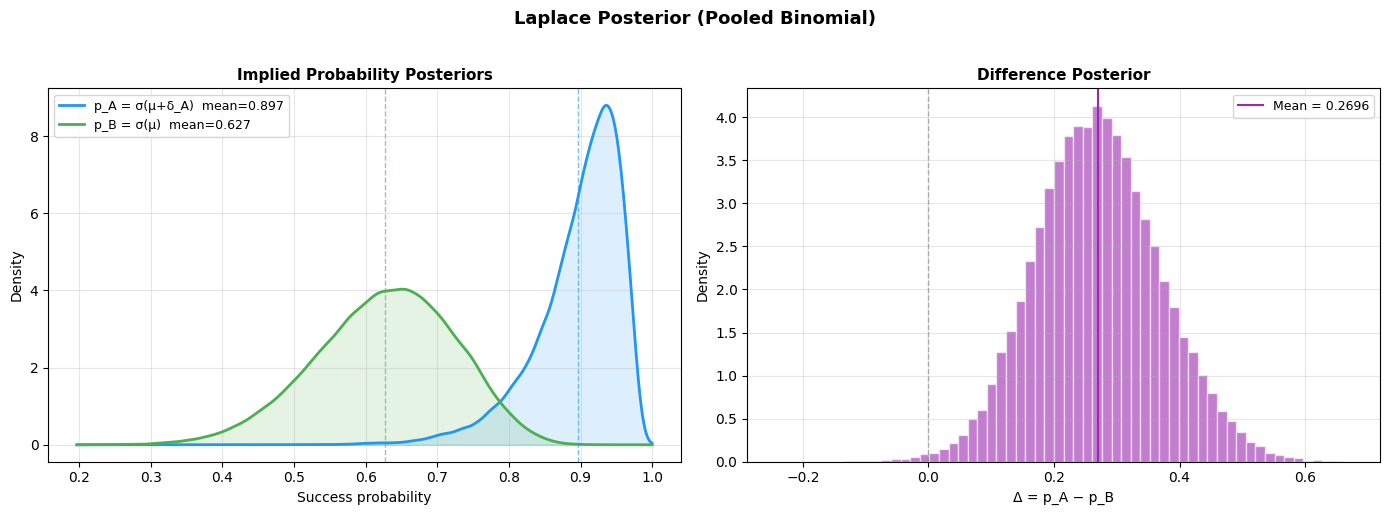

In [ ]:
model.plot_posteriors()
model.plot_posterior_delta()

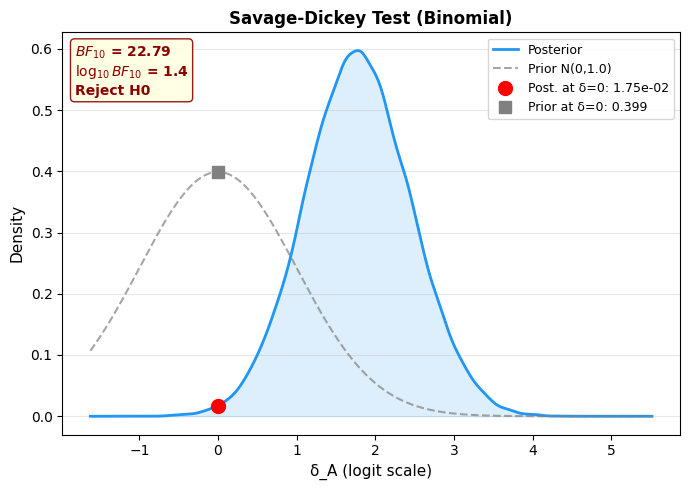

In [8]:
model.plot_savage_dickey()